In [21]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [23]:
df.shape

(891, 15)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## EDA

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [26]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [27]:
df.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [28]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [29]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [20]:
y = df['survived']

In [30]:
X = df.drop(columns = ['survived','alive','deck','class','embark_town'])

Identified leakage columns, removed highly missing features, and avoided duplicate representations of the same information.

In [31]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,female,35.0,1,0,53.1000,S,woman,False,False
4,3,male,35.0,0,0,8.0500,S,man,True,True


In [32]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [33]:
from sklearn.model_selection import train_test_split

In [37]:
y.value_counts(normalize= True)

0    0.616162
1    0.383838
Name: survived, dtype: float64

If we randomly split,the distributions become inconsistent.For classification problems, I used stratified sampling to maintain the target class distribution across train and test datasets.

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify = y)

In [38]:
X_train.shape

(712, 10)

In [39]:
X_test.shape

(179, 10)

In [40]:
y_train.shape

(712,)

In [41]:
y_test.shape

(179,)

In [42]:
# Import preprocessing libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [43]:
# Define numerical and categorical columns

num_features = ['pclass','age','sibsp','parch','fare']
cat_features = ['sex','embarked','who','adult_male','alone']

In [44]:
# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Missing Values
↓
Median Imputation
↓
Scaling

In [45]:
# Categorical Pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Missing Values
↓
Most Frequent Imputation
↓
One Hot Encoding

In [46]:
# Create ColumnTransformer to apply the pipelines correctly

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

ColumnTransformer allows different preprocessing steps to be applied to different subsets of columns within the same pipeline.

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
model = LogisticRegression()

In [49]:
# Create full pipeline

clf = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

now with one command, sklearn will automatically do:

Raw Data
    ↓
Imputation
    ↓
Scaling
    ↓
Encoding
    ↓
Logistic Regression

In [51]:
# Train

clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown=

In [52]:
# Predict
y_pred = clf.predict(X_test)

In [53]:
y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [71]:
# Accuracy

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [55]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.8379888268156425


Ex : 179 passengers in test set

≈ 150 classified correctly
≈ 29 classified incorrectly

In [57]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[98 12]
 [17 52]]


[[TN FP]
 [FN TP]]

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



Precision : When the model predicts "Survived", it is correct 81% of the time.
Recall : Out of all actual survivors, we found 75%.
F1 balances Precision and Recall.

Precision = Quality

Recall = Coverage


## Performance

The model achieved approximately 84% accuracy on the test set. For the positive class, precision was 81%, recall was 75%, and F1-score was 78%. The confusion matrix showed 52 true positives, 98 true negatives, 12 false positives, and 17 false negatives. Overall, the model provided a strong baseline with balanced precision and recall.

In [60]:
y_prob = clf.predict_proba(X_test)

y_prob[:5]

array([[0.94993313, 0.05006687],
       [0.93361731, 0.06638269],
       [0.88617063, 0.11382937],
       [0.96546742, 0.03453258],
       [0.27074963, 0.72925037]])

Probability(Died)     = 94.99%
Probability(Survived) = 5.01%
5.01% < 50%
Prediction becomes : 0 (Did not survive)

In [61]:
# Give me only the probability of survival.
y_prob = clf.predict_proba(X_test)[:,1]

y_prob[:10]

array([0.05006687, 0.06638269, 0.11382937, 0.03453258, 0.72925037,
       0.57146872, 0.79146844, 0.3153896 , 0.33747239, 0.16819332])

In [63]:
pred_50 = y_pred

## Compare number of positive predictions

In [64]:
print("Threshold 0.50")
print(pred_50.sum())

Threshold 0.50
64


In [65]:
pred_30 = (y_prob >= 0.30).astype(int)

print("Threshold 0.30")
print(pred_30.sum())

Threshold 0.30
86


In [66]:
# Calculate Metrics for 0.30 Threshold

from sklearn.metrics import classification_report

print(classification_report(y_test, pred_30))

              precision    recall  f1-score   support

           0       0.89      0.75      0.82       110
           1       0.69      0.86      0.76        69

    accuracy                           0.79       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.81      0.79      0.80       179



### Threshold = 0.50 (Original)
Precision = 0.81
Recall    = 0.75
F1        = 0.78
Accuracy  = 0.84

### Threshold = 0.30
Precision = 0.69
Recall    = 0.86
F1        = 0.76
Accuracy  = 0.79


When we lowered the threshold:The model became more aggressive.
It started saying:survived more often.
Recall Increased : We are catching more actual survivors.
Precision Decreased : Because we're also making more wrong positive predictions.
Accuracy Dropped : expected

Lowering the threshold classifies more observations as positive. This helps capture more true positives, increasing recall, but also increases false positives, reducing precision.

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

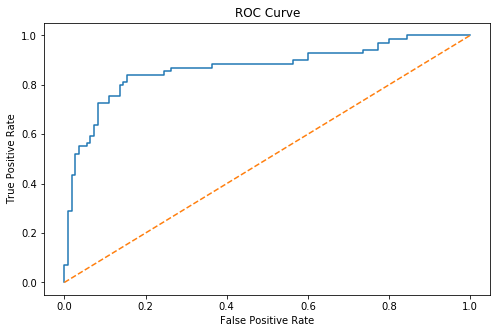

In [70]:
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [72]:
auc = roc_auc_score(y_test, y_prob)

print(auc)

0.8682476943346509


It means the model has an 86.8% probability of ranking a randomly selected survivor higher than a randomly selected non-survivor

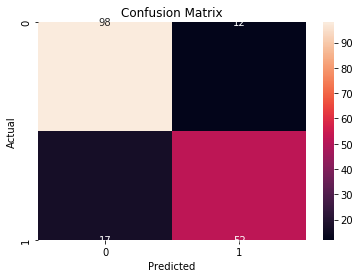

In [73]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


ex: Accuracy is often misleading when a large number of txns are non frauds so it will predict no fraud with great accuracy but AUC tells : 
How well the model separates
Fraud
vs
Non-Fraud

That is why across 
Fraud Detection
Credit Risk
Churn Models
Scam Analytics

this is preferred --> ROC-AUC ,PR-AUC
than accuracy alone.

## Cross validation

Cross Validation evaluates model performance across multiple train-test splits, providing a more stable estimate than a single split.

Dataset
    ↓
Train-Test Split
    ↓
Train Model
    ↓
Evaluate

Suppose we got lucky.Easy passengers → Test set
and accuracy became:84%
    
Another split might reduce the accuracy or even increase the accuracy.
So one split is not always reliable.

What Cross Validation Does:

Imagine:

891 rows  ---> Instead of splitting once: 80% train,20% test --> we split multiple times.

for cv=5, we create:

Fold 1 ,
Fold 2 ,
Fold 3 ,
Fold 4 ,
Fold 5

so , 

Iteration 1 --> 
Train: Fold 2+3+4+5 ,
Test : Fold 1

Iteration 2 -->
Train: Fold 1+3+4+5 ,
Test : Fold 2

Iteration 3 -->
Train: Fold 1+2+4+5 ,
Test : Fold 3 and so on.


In [74]:
from sklearn.model_selection import cross_val_score

In [75]:
cv_scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(cv_scores)

[0.85309618 0.83703209 0.86584225 0.85528075 0.89908257]


In [76]:
print("Mean AUC:", cv_scores.mean())

Mean AUC: 0.8620667656408758


I used 5-fold cross-validation with ROC-AUC as the scoring metric. The model achieved a mean ROC-AUC of approximately 0.862 across folds, indicating stable performance and good generalization.

## Regularization

We have already used LogisticRegression() , but with LogisticRegression(C=1.0) --> C = How much freedom we give the model.
Small C --> Strong regularization
Large C --> weak regularization


###  😄 Very Small C --> Example:

LogisticRegression(C=0.01) --> Model becomes conservative.May underfit.

### 😄 Very Large C --> Example:

LogisticRegression(C=100) --> Model becomes flexible.May overfit.

In [77]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

### Which regularization strength gives the best ROC-AUC?

In [78]:
c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:

    temp_clf = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(C=c))
    ])

    scores = cross_val_score(
        temp_clf,
        X,
        y,
        cv=5,
        scoring='roc_auc'
    )

    print(
        "C =", c,
        "Mean AUC =", round(scores.mean(),4)
    )

C = 0.01 Mean AUC = 0.8635
C = 0.1 Mean AUC = 0.8631
C = 1 Mean AUC = 0.8621
C = 10 Mean AUC = 0.8617
C = 100 Mean AUC = 0.8618


### 😄 Observation

Best AUC  = 0.8635 ,
Worst AUC = 0.8617
Difference: 0.0018 , which is tiny.

The best model is actually: C = 0.01.

People often think: More flexibility --> Better model ----> Not true.

Remember:

Small C
↓
Strong Regularization
↓
Simpler Model ,


Large C
↓
Weak Regularization
↓
More Complex Model

#### RESULTS suggest:

A simpler model generalizes slightly better.

C=0.01 perform slightly better?

Answer:

Stronger regularization reduced model complexity and helped prevent overfitting, leading to slightly better generalization performance during cross-validation.